Dataset shape: (1000, 2), Labels shape: (1000,)
Number of positive samples: 50
Number of negative samples: 950
Class imbalance ratio (Positive : Negative): 50 : 950


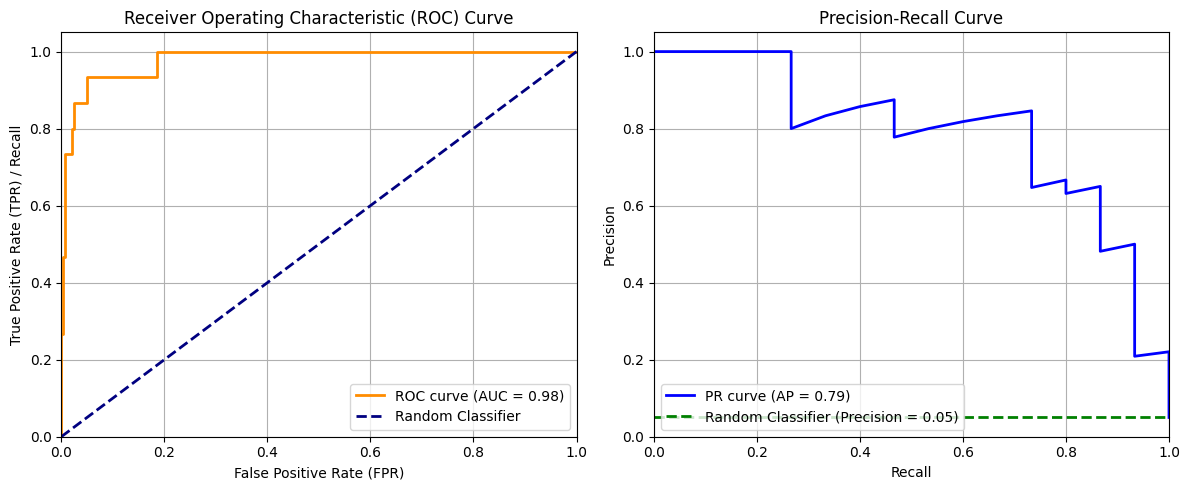


--- Interpretation Example ---
Chosen threshold based on PR curve (targeting Recall ~ 0.8): 0.1981
At this threshold:
  Precision: 0.6316
  Recall (TPR): 0.8000
  FPR (from ROC curve corresponding to this threshold): 0.0246
  Number of positive predictions at this threshold: 19
  True positives: 12
  False positives: 7


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# 1. Generate Synthetic Imbalanced Data
np.random.seed(42)
n_samples = 1000
n_features = 2

# Generate features
X = np.random.randn(n_samples, n_features)

# Generate imbalanced labels
# Let's say only 5% are positive instances (class 1)
n_positive = int(0.05 * n_samples)
n_negative = n_samples - n_positive

# Create clusters for better separation
X_positive = np.random.randn(n_positive, n_features) + [2, 2] # Positive class shifted
X_negative = np.random.randn(n_negative, n_features) - [0.5, 0.5] # Negative class

X = np.vstack((X_positive, X_negative))
y = np.array([1] * n_positive + [0] * n_negative)

# Shuffle the data
shuffle_idx = np.random.permutation(n_samples)
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")
print(f"Number of positive samples: {np.sum(y == 1)}")
print(f"Number of negative samples: {np.sum(y == 0)}")
print(f"Class imbalance ratio (Positive : Negative): {np.sum(y == 1)} : {np.sum(y == 0)}")


# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
) # Stratify to maintain imbalance in splits

# 3. Train a Logistic Regression Model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_scores = model.predict_proba(X_test)[:, 1]

# 4. Plot ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

# 5. Plot Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
average_precision = average_precision_score(y_test, y_scores) # Area under PR curve

plt.subplot(1, 2, 2)
# Note: For PR curves, it's common to plot precision on Y and recall on X
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {average_precision:.2f})')

# Baseline for random classifier: Proportion of positive samples in test set
baseline_precision = np.sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [baseline_precision, baseline_precision], color='green', lw=2, linestyle='--', label=f'Random Classifier (Precision = {baseline_precision:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Interpretation Example (Choosing a threshold)
# Let's find a threshold where Recall is around 0.8 on the PR curve
# We'll pick a threshold from the pr_thresholds array
# For demonstration, let's find the threshold corresponding to a recall close to 0.8
recall_target = 0.8
idx = np.argmin(np.abs(recall - recall_target))
optimal_pr_threshold = pr_thresholds[idx]

# Get precision at this threshold
precision_at_recall_target = precision[idx]

print(f"\n--- Interpretation Example ---")
print(f"Chosen threshold based on PR curve (targeting Recall ~ {recall_target}): {optimal_pr_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision_at_recall_target:.4f}")
print(f"  Recall (TPR): {recall[idx]:.4f}")
print(f"  FPR (from ROC curve corresponding to this threshold): {fpr[np.argmin(np.abs(roc_thresholds - optimal_pr_threshold))]:.4f}")

# Sanity check: How many predictions are positive at this threshold?
y_pred_at_threshold = (y_scores >= optimal_pr_threshold).astype(int)
print(f"  Number of positive predictions at this threshold: {np.sum(y_pred_at_threshold == 1)}")
print(f"  True positives: {np.sum((y_pred_at_threshold == 1) & (y_test == 1))}")
print(f"  False positives: {np.sum((y_pred_at_threshold == 1) & (y_test == 0))}")